<a href="https://colab.research.google.com/github/minaristic1/Household-Animals-Classification/blob/main/03_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Transfer Learning sa VGG-16

U ovom notebook-u implementira se transfer learning pristup za klasifikaciju slika pasa i mačaka korišćenjem unapred istreniranog VGG-16 modela. Konvolucioni deo VGG-16 modela koristi unapred naučene težine sa ImageNet skupa podataka i biće zamrznut tokom prve faze treninga. Na njega će biti dodat prilagođeni klasifikacioni deo za binarnu klasifikaciju klasa cat i dog. Za train, validation i test skup koristi se unapred definisana podela iz fajla split.csv, kreirana u notebook-u 01_data_exploration.ipynb.

In [5]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow verzija:", tf.__version__)

TensorFlow verzija: 2.20.0


In [ ]:
# Montiranje Google Drive-a
from google.colab import drive

drive.mount("/content/drive")

In [6]:
# Provera GPU okruzenja
gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
  print("GPU je dostupan.")
  print("GPU uredjaji:", gpu_devices)
else:
  print("GPU nije dostupan. Proveriti Colab Runtime podesavanja.")

GPU je dostupan.
GPU uredjaji: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# Reproduktivnost
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed postavljen na {SEED}.")

Seed postavljen na 42.


In [8]:
# Ucitavanje split.csv
PROJECT_DIR = "/content/Household-Animals-Classification"
SPLIT_PATH = os.path.join(PROJECT_DIR, "split.csv")
split_df = pd.read_csv(SPLIT_PATH)
print("Dimenzija split tabele:", split_df.shape)
split_df.head()

Dimenzija split tabele: (25000, 3)


,filename,label,split
0,cat.5004.jpg,cat,train
1,dog.9777.jpg,dog,train
2,dog.2406.jpg,dog,train
3,dog.11980.jpg,dog,train
4,cat.10071.jpg,cat,train


In [9]:
# Pregled osnovnih info o split tabeli
split_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  25000 non-null  object
 1   label     25000 non-null  object
 2   split     25000 non-null  object
dtypes: object(3)
memory usage: 586.1+ KB


In [10]:
# Provera mogucih vrednosti za klase i skupove
print("Klase:")
print(split_df["label"].value_counts())

print("\nSplitovi:")
print(split_df["split"].value_counts())

Klase:
label
cat    12500
dog    12500
Name: count, dtype: int64

Splitovi:
split
train    20000
val       4000
test      1000
Name: count, dtype: int64


In [11]:
# Broj slika svake klase unutar svakog skupa
class_distribution = pd.crosstab(split_df["split"], split_df["label"])
class_distribution

label,cat,dog
split,,
test,500,500
train,10000,10000
val,2000,2000


In [12]:
# Provera ispravnosti split tabele
print("Nedostajuce vrednosti:")
print(split_df.isnull().sum())

print("\nBroj dupliranih naziva fajlova:")
print(split_df["filename"].duplicated().sum())

Nedostajuce vrednosti:
filename    0
label       0
split       0
dtype: int64

Broj dupliranih naziva fajlova:
0


In [23]:
EXTRACT_DIR = "/content/drive/MyDrive/MU-projekat/data/dogs-vs-cats"
TRAIN_DIR = os.path.join(EXTRACT_DIR, "train")
DATASET_DIR = os.path.join(TRAIN_DIR, "train")
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"Dataset nije pronađen na putanji: {DATASET_DIR}"
    )

print("Dataset pronađen:", DATASET_DIR)

In [ ]:
# Provera da li svi fajlovi iz split.csv postoje u dataset-u
missing_files = [
    filename
    for filename in split_df["filename"]
    if not os.path.exists(os.path.join(DATASET_DIR, filename))
]

print("Broj fajlova koji nedostaju:", len(missing_files))

if missing_files:
    raise FileNotFoundError(
        f"Nedostaju fajlovi iz split.csv. "
        f"Primeri: {missing_files[:5]}"
    )

print("Svi fajlovi iz split.csv postoje u dataset-u.")

In [20]:
# Kreiranje train, validation i test skupova prema split-u
train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "val"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (20000, 3)
Validation: (4000, 3)
Test: (1000, 3)


In [25]:
# Dodavanje pune putanje do svake slike

train_df["filepath"] = train_df["filename"].apply(
    lambda filename: os.path.join(DATASET_DIR, filename)
)

val_df["filepath"] = val_df["filename"].apply(
    lambda filename: os.path.join(DATASET_DIR, filename)
)

test_df["filepath"] = test_df["filename"].apply(
    lambda filename: os.path.join(DATASET_DIR, filename)
)

train_df.head()

,filename,label,split,filepath
0,cat.5004.jpg,cat,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...
1,dog.9777.jpg,dog,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...
2,dog.2406.jpg,dog,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...
3,dog.11980.jpg,dog,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...
4,cat.10071.jpg,cat,train,/content/drive/MyDrive/MU-projekat/data/dogs-v...


In [27]:
print("Train fajlovi postoje:",
      train_df["filepath"].apply(os.path.exists).all())

print("Validation fajlovi postoje:",
      val_df["filepath"].apply(os.path.exists).all())

print("Test fajlovi postoje:",
      test_df["filepath"].apply(os.path.exists).all())

Train fajlovi postoje: True
Validation fajlovi postoje: True
Test fajlovi postoje: True


In [28]:
# Osnovni parametri za ucitavanje slika.
IMG_SIZE = 224
BATCH_SIZE = 32

print("Velicina slike:", IMG_SIZE, "x", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Velicina slike: 224 x 224
Batch size: 32


In [29]:
# Mapiranje klasa
CLASS_NAMES = ["cat", "dog"]

label_to_index = {"cat": 0, "dog":1}
print("Mapiranje klasa:", label_to_index)

Mapiranje klasa: {'cat': 0, 'dog': 1}


In [30]:
# Dodavanje numericke oznake klase
train_df["label_index"] = train_df["label"].map(label_to_index)
val_df["label_index"] = val_df["label"].map(label_to_index)
test_df["label_index"] = test_df["label"].map(label_to_index)

train_df[["filename", "label", "label_index"]].head()

,filename,label,label_index
0,cat.5004.jpg,cat,0
1,dog.9777.jpg,dog,1
2,dog.2406.jpg,dog,1
3,dog.11980.jpg,dog,1
4,cat.10071.jpg,cat,0


In [31]:
print("Train labele:", sorted(train_df["label_index"].unique()))
print("Validation labele:", sorted(val_df["label_index"].unique()))
print("Test labele:", sorted(test_df["label_index"].unique()))

Train labele: [np.int64(0), np.int64(1)]
Validation labele: [np.int64(0), np.int64(1)]
Test labele: [np.int64(0), np.int64(1)]


In [37]:
# Funkcija za ucitavanje slike.
from tensorflow.keras.applications.vgg16 import preprocess_input

def load_image(filepath, label):
    # Učitavanje slike sa diska
    image = tf.io.read_file(filepath)

    # Dekodiranje JPEG slike u RGB tensor
    image = tf.image.decode_jpeg(image, channels=3)

    # Promena veličine slike na dimenzije koje očekuje VGG-16
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Konverzija piksela u float32
    image = tf.cast(image, tf.float32)

    # Labela se koristi kao float32 zbog binarne klasifikacije
    label = tf.cast(label, tf.float32)

    return image, label


In [38]:
# Testiranje funkcije na jednom primeru

sample_filepath = train_df.iloc[0]["filepath"]
sample_label = train_df.iloc[0]["label_index"]

sample_image, sample_label_tensor = load_image(
    sample_filepath,
    sample_label
)

print("Oblik slike:", sample_image.shape)
print("Tip slike:", sample_image.dtype)
print("Labela:", sample_label_tensor.numpy())

Oblik slike: (224, 224, 3)
Tip slike: <dtype: 'float32'>
Labela: 0.0


In [39]:
# Kreiranje TensorFlow dataseta
def create_dataset(df, training=False):
    filepaths = df["filepath"].values
    labels = df["label_index"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [42]:
train_dataset = create_dataset(
    train_df,
    training=True
)

val_dataset = create_dataset(
    val_df,
    training=False
)

test_dataset = create_dataset(
    test_df,
    training=False
)

print("Train dataset:", train_dataset)
print("Validation dataset:", val_dataset)
print("Test dataset:", test_dataset)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [43]:
# Provera jednog batch-a

for images, labels in train_dataset.take(1):
    print("Oblik batch-a slika:", images.shape)
    print("Oblik batch-a labela:", labels.shape)
    print("Tip slika:", images.dtype)
    print("Tip labela:", labels.dtype)
    print("Minimalna vrednost piksela:", tf.reduce_min(images).numpy())
    print("Maksimalna vrednost piksela:", tf.reduce_max(images).numpy())

Oblik batch-a slika: (32, 224, 224, 3)
Oblik batch-a labela: (32,)
Tip slika: <dtype: 'float32'>
Tip labela: <dtype: 'float32'>
Minimalna vrednost piksela: 0.0
Maksimalna vrednost piksela: 255.0


In [48]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomZoom(0.1, seed=SEED),
], name="data_augmentation")


In [44]:
# Ucitavanje VGG-16 konvolucione baze.
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

print("VGG-16 konvoluciona baza je učitana.")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG-16 konvoluciona baza je učitana.


In [46]:
base_model.summary()
print("Ukupan broj slojeva:", len(base_model.layers))
print("Broj trainable slojeva:",sum(layer.trainable for layer in base_model.layers))

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

Ukupan broj slojeva: 19
Broj trainable slojeva: 0


In [49]:
# Kreiranje transfer learning modela
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Data augmentation se primenjuje samo tokom treninga
x = data_augmentation(inputs)

# Preprocesiranje koje očekuje VGG-16
x = preprocess_input(x)

# Zamrznuta VGG-16 konvoluciona baza
x = base_model(x, training=False)

# Sažimanje feature mapa u jedan vektor
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Dense sloj prilagođen našem problemu
x = tf.keras.layers.Dense(256, activation="relu")(x)

# Regularizacija radi smanjenja overfitting-a
x = tf.keras.layers.Dropout(0.5)(x)

# Jedan izlazni neuron za binarnu klasifikaciju
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="vgg16_transfer_learning")

In [52]:
model.summary()
# Provera broja parametara modela

trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
])

print("Trainable parametri:", trainable_params)
print("Non-trainable parametri:", non_trainable_params)

Model: "vgg16_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Trainable parametri: 131585
Non-trainable parametri: 14714688


In [53]:
# Kompajliranje modela
LEARNING_RATE = 1e-3

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print("Model je uspešno kompajliran.")
print("Learning rate:", LEARNING_RATE)

Model je uspešno kompajliran.
Learning rate: 0.001


In [54]:
# Callbacks funkcija za kontrolu treninga.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [55]:
# Trening transfer learning modela
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 178ms/step - accuracy: 0.9617 - loss: 0.1335 - val_accuracy: 0.9852 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 136s 180ms/step - accuracy: 0.9757 - loss: 0.0661 - val_accuracy: 0.9835 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 109s 175ms/step - accuracy: 0.9800 - loss: 0.0542 - val_accuracy: 0.9885 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 145s 180ms/step - accuracy: 0.9809 - loss: 0.0535 - val_accuracy: 0.9875 - val_loss: 0.0367 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9829 - loss: 0.0460
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 177ms/step - accuracy: 0.9811 - loss: 0.0497 - val_accuracy: 0.9860 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 177ms/step - accuracy:

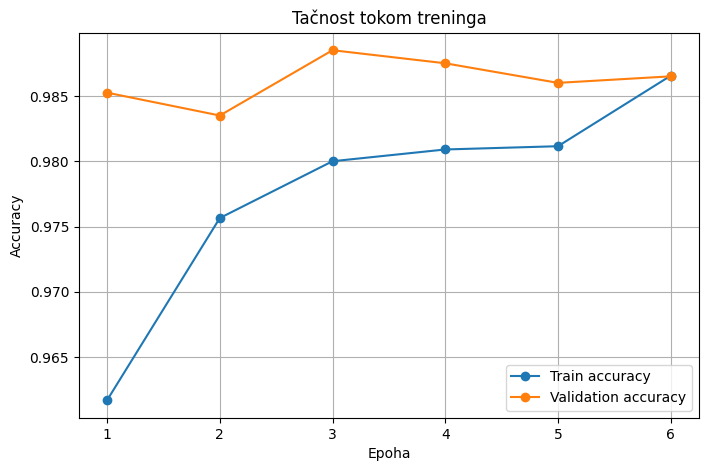

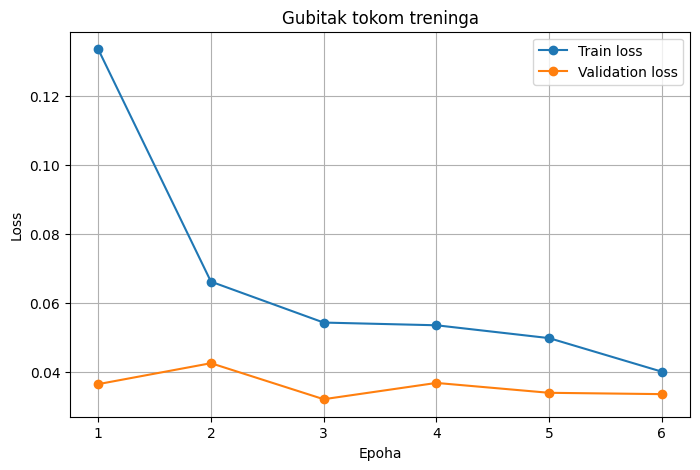

In [56]:
# Vizualizacija toka treninga.
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)

# Accuracy kroz epohe
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_accuracy, marker="o", label="Train accuracy")
plt.plot(epochs_range, val_accuracy, marker="o", label="Validation accuracy")

plt.xlabel("Epoha")
plt.ylabel("Accuracy")
plt.title("Tačnost tokom treninga")
plt.legend()
plt.grid()

plt.show()

# Loss kroz epohe
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_loss, marker="o", label="Train loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation loss")

plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.title("Gubitak tokom treninga")
plt.legend()
plt.grid()

plt.show()

In [57]:
# Evaluacija modela na test skupu.
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy (%): {test_accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.9810 - loss: 0.0425
Test loss: 0.0425
Test accuracy: 0.9810
Test accuracy (%): 98.10%


In [58]:
# Predikcija na test skupu
y_prob = model.predict(
    test_dataset,
    verbose=1
).ravel()

# Sigmoid izlaz pretvaramo u klase 0 i 1
y_pred = (y_prob >= 0.5).astype(int)

# Stvarne labele test skupa
y_true = test_df["label_index"].to_numpy()

print("Broj predikcija:", len(y_pred))
print("Broj stvarnih labela:", len(y_true))

print("Prvih 10 verovatnoća:")
print(y_prob[:10])

print("\nPrvih 10 predikovanih klasa:")
print(y_pred[:10])

print("\nPrvih 10 stvarnih klasa:")
print(y_true[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step
Broj predikcija: 1000
Broj stvarnih labela: 1000
Prvih 10 verovatnoća:
[2.9240538e-12 7.6404685e-05 1.7984512e-03 9.9999893e-01 8.7402750e-12
 1.3402006e-05 1.0000000e+00 1.5382026e-05 6.6356765e-06 1.4436303e-05]

Prvih 10 predikovanih klasa:
[0 0 0 1 0 0 1 0 0 0]

Prvih 10 stvarnih klasa:
[0 0 0 1 0 0 1 0 0 0]


In [60]:
# Precision, recall i F1-score.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

Accuracy:  0.9810
Precision: 0.9839
Recall:    0.9780
F1-score:  0.9809
              precision    recall  f1-score   support

         cat     0.9781    0.9840    0.9811       500
         dog     0.9839    0.9780    0.9809       500

    accuracy                         0.9810      1000
   macro avg     0.9810    0.9810    0.9810      1000
weighted avg     0.9810    0.9810    0.9810      1000



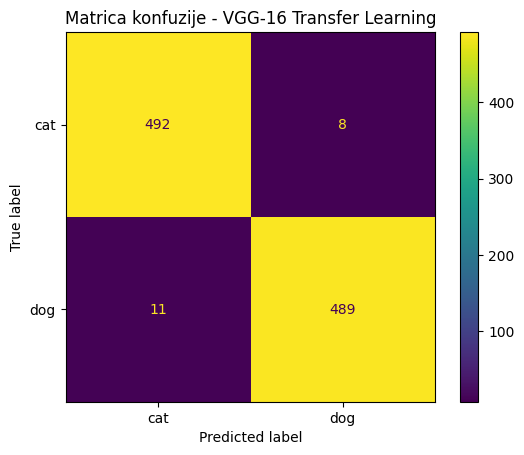

In [61]:
# Matrica konfuzije
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Matrica konfuzije - VGG-16 Transfer Learning")
plt.show()

In [62]:
print("Matrica konfuzije:")
print(cm)

Matrica konfuzije:
[[492   8]
 [ 11 489]]


## Zaključak

Transfer learning model zasnovan na VGG-16 arhitekturi postigao je veoma dobre rezultate na test skupu.

Konvoluciona baza VGG-16 modela, prethodno istrenirana na ImageNet skupu, bila je zamrznuta, dok je treniran samo prilagođeni klasifikacioni deo modela.

Na test skupu dobijeni su sledeći rezultati:
- Accuracy: 98.10%
- Precision: 98.39%
- Recall: 97.80%
- F1-score: 98.09%

Matrica konfuzije pokazuje da je model ispravno klasifikovao 492 od 500 slika mačaka i 489 od 500 slika pasa. Pogrešno je klasifikovano 8 mačaka kao pasa i 11 pasa kao mačaka.

In [63]:
# Cuvanje transfer learning modela
MODEL_DIR = "/content/drive/MyDrive/MU-projekat/models"
os.makedirs(MODEL_DIR, exist_ok=True)

TRANSFER_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "vgg16_transfer_learning.keras"
)

model.save(TRANSFER_MODEL_PATH)

print("Model je sačuvan na:")
print(TRANSFER_MODEL_PATH)
print(
    "Model uspešno sačuvan:",
    os.path.exists(TRANSFER_MODEL_PATH)
)

Model je sačuvan na:
/content/drive/MyDrive/MU-projekat/models/vgg16_transfer_learning.keras
Model uspešno sačuvan: True
